# NudgeIQ

## Notebook 01: Behavioral Evidence Extraction

### Objective

This notebook performs the initial data assessment for the Bank Marketing dataset.

The workflow includes:

- Data loading
- Data quality assessment
- Exploratory Data Analysis (EDA)
- Behavioural evidence extraction
- Saving cleaned data for downstream AI models

Output:
- behavioral_data.csv

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import RAW_DIR, PROCESSED_DIR
from src.utils import load_dataset, print_section

In [14]:
print_section("Loading Dataset")

df = load_dataset(RAW_DIR / "bank.csv", separator=",")

print(f"Dataset Shape : {df.shape}")

df.head()


Loading Dataset
Dataset Shape : (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [15]:
print_section("Column Information")

df.info()


Column Information
<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [16]:
print_section("Summary Statistics")

display(df.describe())

display(df.describe(include="object"))


Summary Statistics


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


C:\Users\Madhuvarshini\AppData\Local\Temp\ipykernel_11452\3838024239.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


In [17]:
print_section("Missing Values")

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

display(missing)


Missing Values


,Missing Values,Percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


In [18]:
print_section("Duplicate Records")

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")


Duplicate Records
Duplicate Rows : 0


In [19]:
print_section("Target Variable")

display(df["deposit"].value_counts())

display(
    round(
        df["deposit"].value_counts(normalize=True)*100,
        2
    )
)


Target Variable


deposit
no     5873
yes    5289
Name: count, dtype: int64

deposit
no     52.62
yes    47.38
Name: proportion, dtype: float64

In [20]:
print_section("Dataset Metadata")

metadata = pd.DataFrame({
    "Column": df.columns,
    "Datatype": df.dtypes.values,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

display(metadata)


Dataset Metadata


,Column,Datatype,Unique Values
0,age,int64,76
1,job,str,12
2,marital,str,3
3,education,str,4
4,default,str,2
5,balance,int64,3805
6,housing,str,2
7,loan,str,2
8,contact,str,3
9,day,int64,31


In [21]:
print_section("Saving Dataset")

output_path = PROCESSED_DIR / "behavioral_data.csv"

df.to_csv(output_path, index=False)

print(f"Saved Successfully : {output_path}")


Saving Dataset
Saved Successfully : D:\NudgeIQ\data\processed\behavioral_data.csv


In [22]:
print_section("Numerical Features")

df.describe().T


Numerical Features


,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0



Age Distribution


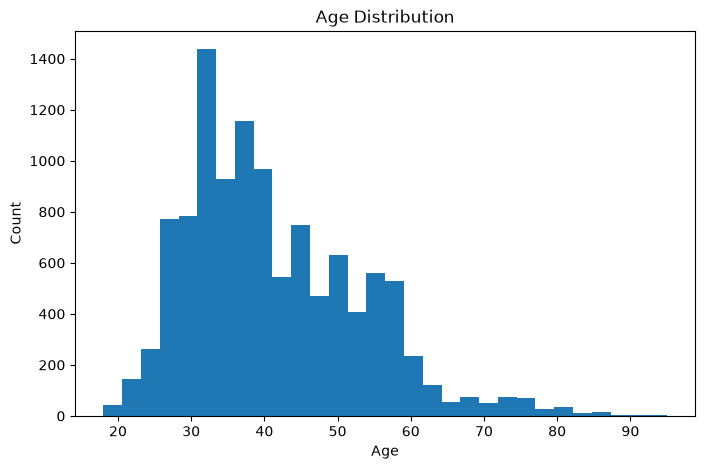

In [23]:
print_section("Age Distribution")

plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

Most customers are between 30 and 50 years old.

The dataset contains very few customers below 20 or above 70.
### Observation

- The majority of customers fall between 30 and 45 years of age.
- The customer base gradually decreases after the age of 50.
- Very few customers are above 70 years, indicating that the bank primarily serves working-age individuals.


Job Distribution


job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

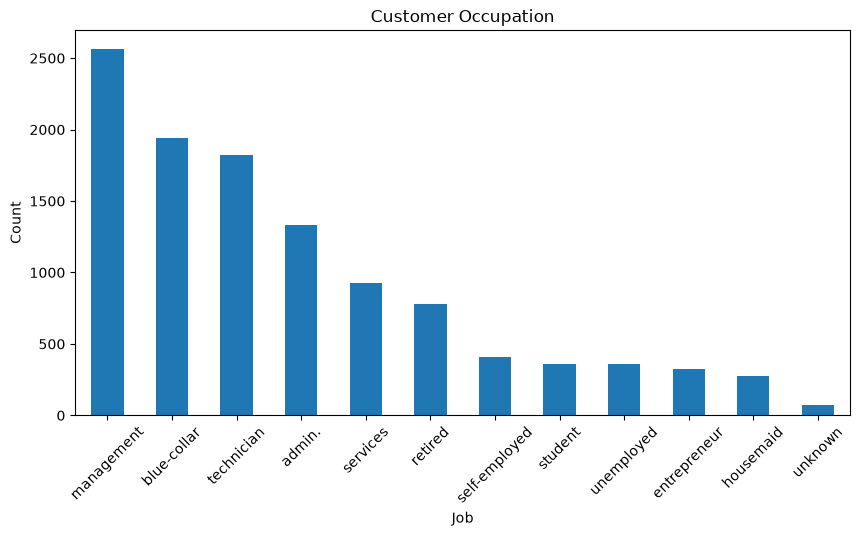

In [24]:
print_section("Job Distribution")

job_counts = df["job"].value_counts()

display(job_counts)

plt.figure(figsize=(10,5))

job_counts.plot(kind="bar")

plt.title("Customer Occupation")

plt.xlabel("Job")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Observation

- Management professionals form the largest customer segment.
- Blue-collar and technician occupations also contribute significantly.
- Only a small proportion of customers belong to the entrepreneur or housemaid categories.


Marital Status


marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

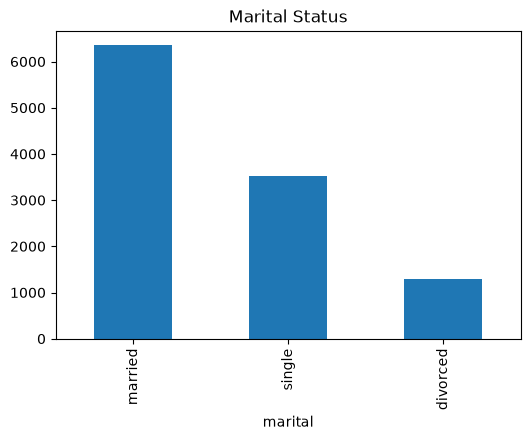

In [25]:
print_section("Marital Status")

display(df["marital"].value_counts())

plt.figure(figsize=(6,4))

df["marital"].value_counts().plot(kind="bar")

plt.title("Marital Status")

plt.show()

Most customers are married.


Education Level


education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

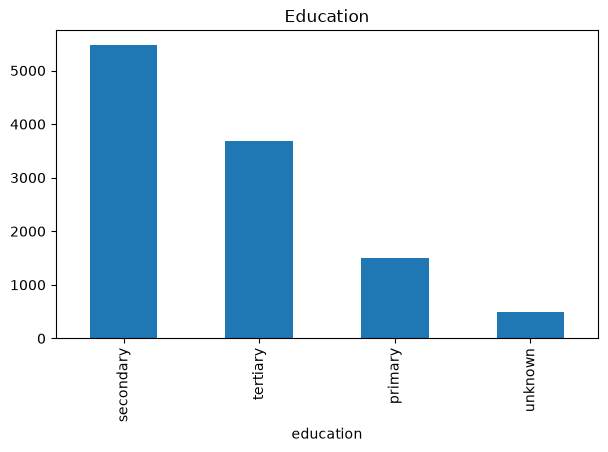

In [26]:
print_section("Education Level")

display(df["education"].value_counts())

plt.figure(figsize=(7,4))

df["education"].value_counts().plot(kind="bar")

plt.title("Education")

plt.show()

Secondary education dominates the dataset.


Deposit Outcome


deposit
no     5873
yes    5289
Name: count, dtype: int64

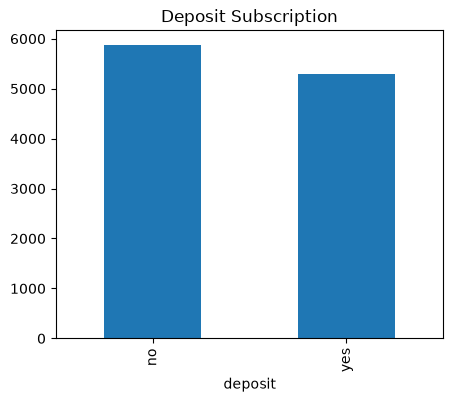

In [27]:
print_section("Deposit Outcome")

display(df["deposit"].value_counts())

plt.figure(figsize=(5,4))

df["deposit"].value_counts().plot(kind="bar")

plt.title("Deposit Subscription")

plt.show()

This shows whether the dataset is balanced or imbalanced.
### Observation

- The target variable is reasonably balanced.
- Around half of the customers subscribed to a deposit product.
- This balance is beneficial for predictive modeling because it reduces the risk of model bias.

In [28]:
print_section("Correlation Matrix")

corr = df.corr(numeric_only=True)

display(corr)


Correlation Matrix


,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.112300,-0.000762,0.000189,-0.005278,0.002774,0.020169
balance,0.112300,1.000000,0.010467,0.022436,-0.013894,0.017411,0.030805
day,-0.000762,0.010467,1.000000,-0.018511,0.137007,-0.077232,-0.058981
duration,0.000189,0.022436,-0.018511,1.000000,-0.041557,-0.027392,-0.026716
campaign,-0.005278,-0.013894,0.137007,-0.041557,1.000000,-0.102726,-0.049699
pdays,0.002774,0.017411,-0.077232,-0.027392,-0.102726,1.000000,0.507272
previous,0.020169,0.030805,-0.058981,-0.026716,-0.049699,0.507272,1.000000


## Key Findings

- Dataset contains 11,162 customer records.
- No missing values were observed.
- Majority of customers are aged between 30–50 years.
- Married customers form the largest segment.
- Secondary education is the most common education level.
- Administrative, technician, and blue-collar occupations dominate.
- Deposit subscription is the target variable for predictive modeling.

In [31]:
print_section("Categorical Features")

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Categorical Features

job
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

marital
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

education
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

default
default
no     10994
yes      168
Name: count, dtype: int64

housing
housing
no     5881
yes    5281
Name: count, dtype: int64

loan
loan
no     9702
yes    1460
Name: count, dtype: int64

contact
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64

month
month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
oct     392
jan     344
sep     319
mar     276
dec     110
Name: count, dt

C:\Users\Madhuvarshini\AppData\Local\Temp\ipykernel_11452\3169877730.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [33]:
print_section("Data Quality Report")

quality = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing": df.isnull().sum(),
    "Unique": df.nunique(),
    "Duplicates": [df.duplicated().sum()] + [""]*(len(df.columns)-1)
})

quality


Data Quality Report


,Data Type,Missing,Unique,Duplicates
age,int64,0,76,0
job,str,0,12,
marital,str,0,3,
education,str,0,4,
default,str,0,2,
balance,int64,0,3805,
housing,str,0,2,
loan,str,0,2,
contact,str,0,3,
day,int64,0,31,


In [34]:
print_section("Saving Processed Dataset")

output_file = PROCESSED_DIR / "behavioral_data.csv"

df.to_csv(output_file, index=False)

print("Saved Successfully!")

print(output_file)


Saving Processed Dataset
Saved Successfully!
D:\NudgeIQ\data\processed\behavioral_data.csv
